1. What is a Support Vector Machine (SVM)?

Answer:A Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for both classification (SVC) and regression (SVR). Since we are currently working on an SVM_regressor, we will focus on the logic behind how it finds a "best fit" for our data.In classification, an SVM tries to find a Hyperplane (a decision boundary) that separates classes with the widest possible margin. In regression (SVR), the goal is flipped: it tries to fit the hyperplane within a certain distance of as many data points as possible.

2. What is the difference between Hard Margin and Soft Margin SVM?

## **1\. Hard Margin SVM**

A Hard Margin SVM is a strict classifier. It requires that **every single data point** be correctly classified and stay outside the margin.

* **Requirement:** The data must be **perfectly linearly separable** (you can draw a straight line or plane that perfectly divides the classes).  
* **Sensitivity:** It is extremely sensitive to outliers. A single outlier that is closer to the other class than the rest of its group will "squash" the margin, making the model very narrow and potentially useless.  
* **Risk:** High risk of **Overfitting**, as it tries too hard to accommodate every specific point in the training set.

## **2\. Soft Margin SVM**

A Soft Margin SVM is a more flexible version that allows for some "mistakes." It allows some points to cross the margin or even end up on the wrong side of the boundary.

* **The "Slack" Variable ($\xi$):** To allow for overlap, we introduce "Slack Variables." These represent how much a specific point violates the margin.  
* **Applicability:** This is used for real-world data, which is rarely perfectly separable and often contains noise or overlapping clusters.  
* **The C Parameter:** This is the "Budget" for errors. It controls the trade-off between maximizing the margin and minimizing the slack (errors).

## **3\. Comparison Table**

| Feature | Hard Margin SVM | Soft Margin SVM |
| :---- | :---- | :---- |
| **Outlier Handling** | Strict: No outliers allowed inside the margin. | Flexible: Allows points to violate the margin. |
| **Data Separability** | Data must be perfectly separable. | Works with messy, overlapping data. |
| **Goal** | Find the widest margin with zero errors. | Balance margin width vs. error count. |
| **Complexity** | Simpler mathematically but fragile. | More robust and generalizes better. |
| **Overfitting** | High risk (sensitive to noise). | Low risk (controlled by C parameter). |

3. What is the mathematical intuition behind SVM?

Answer:
## The Mathematical Intuition of SVM

Support Vector Machines (SVM) are rooted in Optimization Theory and Linear Algebra. Here is the step-by-step mathematical logic of how the algorithm "thinks."

# 1. Defining the Hyperplane

In a 2D space, a boundary is a line. In 3D, it's a plane. In $N$ dimensions, it is a Hyperplane.
The mathematical equation for this hyperplane is:

$$w^T x + b = 0$$

* $w$: The weight vector (orthogonal to the hyperplane, defining its orientation).

* $x$: The input features.

* $b$: The bias (shaping the distance from the origin).

# 2. The Geometry of the Margin

SVM doesn't just want any line that separates the data; it wants the one with the Maximum Margin.

Functional Margin

For a data point $(x_i, y_i)$, the functional margin is $y_i(w^T x_i + b)$.

* If this value is positive, the point is correctly classified.

* If it is large, the model is very "confident."

Geometric Margin

This is the actual Euclidean distance from the point to the hyperplane. To find the "best" line, we maximize this distance for the points closest to the boundary.
The distance from a point $x_i$ to the hyperplane is:

$$\gamma_i = \frac{y_i(w^T x_i + b)}{\|w\|}$$

3. The Objective Function (Hard Margin)

The goal is to maximize the margin ($M = \frac{2}{\|w\|}$).
In mathematics, maximizing $\frac{2}{\|w\|}$ is the same as minimizing $\frac{1}{2}\|w\|^2$.

The Optimization Problem:


$$\min_{w, b} \frac{1}{2}\|w\|^2$$


Subject to:


$$y_i(w^T x_i + b) \geq 1 \quad \text{for all } i$$

This is a Quadratic Programming problem. The constraint $y_i(w^T x_i + b) \geq 1$ ensures that all points stay outside the "gutters" (margins).

4. Support Vectors: The "Pillars"

During optimization, most data points don't actually matter. Only the points where the constraint is "active" ($y_i(w^T x_i + b) = 1$) affect the position of the line.
These are the Support Vectors. If you move any other point, the weights $w$ stay the same.

5. The Kernel Trick: Higher Dimensions

What if the data is a circle (not linearly separable)?
SVM uses the Dual Formulation of the optimization problem, where the features only appear as a Dot Product ($x_i \cdot x_j$).

Instead of physically calculating a 3D projection (which is slow), we use a Kernel Function $K(x_i, x_j)$ that calculates the dot product as if the data were already in that higher dimension.

Common Kernels:

* Linear: $K(x, z) = x^T z$

* Polynomial: $K(x, z) = (x^T z + c)^d$

* RBF (Gaussian): $K(x, z) = \exp(-\gamma \|x - z\|^2)$

Intuition: RBF measures the "similarity" between points. If they are close, the kernel value is high.

6. SVR: Regression Intuition

Since you are working on an SVM_regressor, the math flips. Instead of pushing points outside the margin, SVR tries to fit as many points as possible inside a tube of width Epsilon ($\epsilon$).

Error Tolerance: Points inside the tube have a loss of 0.

The Goal: Minimize $\frac{1}{2}\|w\|^2$ while keeping the prediction error within $\epsilon$.

4. What is the role of Lagrange Multipliers in SVM?

## The Role of Lagrange Multipliers in SVM
In mathematical optimization, Lagrange Multipliers are used to find the local maxima and minima of a function subject to equality or inequality constraints. In Support Vector Machines, they are the secret to turning a difficult optimization problem into a solvable one.
# 1. The Optimization Challenge
 the goal of a Hard Margin SVM is to:
* Minimize:   $\frac{1}{2}\|w\|^2$ (to maximize the margin).
* Subject to: $y_i(w^T x_i + b) \geq 1$ for all  (ensuring all points are correctly classified).
This is a Constrained Optimization problem. You cannot simply take the derivative and set it to zero because of the inequality constraints ($\geq 1$).
# 2. The Lagrangian Function
To solve this, we combine the objective function and the constraints into a single equation called the Lagrangian:
$$L(w, b, \alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^{n} \alpha_i [y_i(w^T x_i + b) - 1]$$
* $\alpha_i$: These are the Lagrange Multipliers.
* There is one multiplier  for every single data point in your training set.
# 3. Primal vs. Dual Problem
Lagrange multipliers allow us to switch from the Primal Problem (solving for $w$ and $b$) to the Dual Problem (solving for $\alpha$).
Why the Dual Problem is better:
1. Elimination of $w$ and $b$: By taking derivatives of $L$ with respect to $w$ and $b$ and setting them to zero, we find that $w = \sum \alpha_i y_i x_i$.
2. Dot Products: When we plug this back in, the optimization depends only on the dot product of the data points ($x_i \cdot x_j$).
3. The Kernel Trick: Because the formula only uses dot products, we can replace ($x_i \cdot x_j$) with a Kernel Function  $K(x_i, x_j)$. This allows SVM to operate in infinite-dimensional spaces without ever actually calculating the coordinates in that space.
# 4. Identifying Support Vectors (KKT Conditions)
The Lagrange Multipliers () reveal which points are the "Support Vectors." According to the Karush-Kuhn-Tucker (KKT) complementary slackness condition:

$$\alpha_i [y_i(w^T x_i + b) - 1] = 0$$

This leads to two fascinating results for every data point:
* Case 1: $\alpha_i = 0$ The point is "safe" and lies outside the margin. It has zero influence on the final model. Most of your multipliers will end up being zero, which is why SVMs are memory efficient (Sparsity).

* Case 2: $\alpha_i > 0$ For the product to be zero, the term in the bracket must be zero, meaning $y_i(w^T x_i + b) = 1$. This point lies exactly on the margin. These are the Support Vectors—the only points that determine the decision boundary.


5. What are Support Vectors in SVM?

Answer:Support Vectors are the critical data points from the training set that lie closest to the decision boundary (hyperplane). They are called "Support Vectors" because they literally "support" or define the position and orientation of the hyperplane. If these specific points were moved or removed, the decision boundary of the model would change.

6. What is a Support Vector Classifier (SVC)?

Answer:A Support Vector Classifier (SVC) is a supervised machine learning algorithm used for classification tasks. It is the classification-specific application of the Support Vector Machine (SVM) framework. The primary goal of an SVC is to find the best possible boundary (known as a hyperplane) that separates data points of different classes with the highest degree of confidence.

7. What is a Support Vector Regressor (SVR)?

Answer:Support Vector Regression (SVR) is a type of Support Vector Machine (SVM) that is used for regression tasks. While a standard SVM is designed to find a hyperplane that separates classes (Classification), SVR seeks a function that predicts a continuous value (Regression).

8. What is the Kernel Trick in SVM?

Answer:
# **The Kernel Trick in Support Vector Machines (SVM)**

The **Kernel Trick** is a mathematical technique that allows Support Vector Machines (SVMs) to solve non-linear classification problems efficiently. It enables the algorithm to operate in a high-dimensional space without ever actually calculating the coordinates of the data in that space.

## **1\. The Core Problem: Non-Linearity**

Standard SVMs are **linear classifiers**. They try to find a straight line (in 2D) or a flat plane (in 3D) to separate two classes. However, real-world data is often "tangled."

**Example:** Imagine a "donut" dataset where Class A is a circle in the center and Class B is a ring surrounding it. In 2D, no straight line can separate them.

## **2\. The Solution: "Lifting" to Higher Dimensions**

To separate the "donut," you could project the 2D points into 3D.
If you map each point $(x, y)$ to a new coordinate $z = x^2 + y^2$:

* The inner circle points (small $x, y$) will have low $z$ values (sit at the bottom of a bowl).

* The outer ring points (large $x, y$) will have high $z$ values (sit higher up).

In this new 3D space, a flat 2D plane can easily slice between the two groups. This transformation is called a Feature Map, denoted as $\phi(x)$.

# The Computational "Wall"

Transforming every data point into a higher dimension is extremely expensive. If you have 1,000 features and want to use a high-degree polynomial, you might end up with millions of dimensions. Calculating and storing these new coordinates would crash most computers.

## **3\. The "Trick": Skip the Transformation**

The "trick" relies on a mathematical realization: The SVM algorithm doesn't actually need the coordinates ($\phi(x)$) of the points; it only needs the dot products between them.

In the SVM optimization formula, data points only appear as:


$$\phi(x_i) \cdot \phi(x_j)$$

A Kernel Function $K(x_i, x_j)$ is a shortcut that calculates what that dot product would be in the high-dimensional space, using only the original, low-dimensional coordinates.

| Approach | Process | Cost |
| :---- | :---- | :---- |
| **Traditional** | **$x \to \phi(x) \to \text{Calculate Dot Product}$** | Very High |
| **Kernel Trick** | **$x \to K(x_i, x_j)$** | Very Low |


9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.

## **1\. Common Kernel Functions**

Linear Kernel

Used when data is already linearly separable. It’s just the standard dot product.

$$K(x, y) = x \cdot y$$

Polynomial Kernel

Good for image processing and modeling feature interactions.

$$K(x, y) = (x \cdot y + c)^d$$

Where $d$ is the degree (e.g., $d=2$ for squares, $d=3$ for cubes).

Radial Basis Function (RBF / Gaussian)

The most popular kernel. It can handle almost any boundary shape and effectively maps data into an infinite-dimensional space.

$$K(x, y) = \exp(-\gamma \|x - y\|^2)$$

Small $\gamma$ creates a smooth boundary; large $\gamma$ creates "islands" around data points (potential overfitting).

## **2\. Comparison of Kernels**

Selecting the right kernel is crucial for model performance. Below is a comparison of the three most common types:

| Feature | Linear Kernel | Polynomial Kernel | RBF (Gaussian) Kernel |
| :---- | :---- | :---- | :---- |
| **Best For** | High-dimensional data (e.g., Text) | Interaction between features | General non-linear data |
| **Boundary** | Straight line/plane | Curved / Complex | Highly Complex / "Islands" |
| **Parameters** | None | Degree ($d$), Constant ($c$) | Gamma ($\gamma$) |
| **Overfit Risk** | Low | High (with high degree) | High (with high $\gamma$) |
| **Speed** | Fastest | Medium | Slower |
| **Key Advantage** | Simple and fast | Captures feature interaction | Most flexible and powerful |

10. What is the effect of the C parameter in SVM?

Answer:
## The $C$ Parameter: Managing Errors

While the kernel defines the shape of the boundary, the $C$ parameter (Regularization parameter) defines the tolerance for classification errors. It tells the SVM how much you want to avoid misclassifying each training example.

* Small $C$ (Soft Margin): The model prioritizes a larger margin, even if it means misclassifying some points. This makes the model simpler and better at generalizing to new data (lower variance, higher bias).

* Large $C$ (Hard Margin): The model prioritizes correctly classifying all training points, even if the margin becomes very narrow. This can lead to overfitting as the model tries too hard to fit every outlier (high variance, lower bias).

| Parameter Value | Priority | Result |
| :---- | :---- | :---- |
| **Small $C$** | Large Margin | Better generalization, ignores outliers |
| **Large $C$** | Zero Errors | Overfitting risk, fits every outlier |

11. What is the role of the Gamma parameter in RBF Kernel SVM?

Answer:
## The Gamma ($\gamma$) Parameter: Defining Influence

In the RBF kernel, the Gamma ($\gamma$) parameter defines how far the influence of a single training example reaches. You can think of it as the "reach" or "spread" of each data point's influence.

* Small Gamma: A single point has a far-reaching influence. This leads to a smoother, simpler decision boundary. The model behaves more like a linear classifier.

* Large Gamma: A single point has a very close-range influence. The decision boundary will be very "wiggly" and tightly constrained to individual points. This often leads to high-variance models that overfit the training data.

| Parameter Value | Influence Reach | Boundary Shape | Overfitting Risk |
| :---- | :---- | :---- | :---- |
| **Small $\gamma$** | Far / Broad | Smooth / Simple | Low |
| **Large $\gamma$** | Near / Point-specific | Curvy / Complex | High |

12. What is the Naïve Bayes classifier, and why is it called "Naïve"?

Answer:
## 1. What is Naïve Bayes?

At its core, Naïve Bayes is a probabilistic classifier. This means it doesn't just give you a "Yes" or "No" label; it calculates the probability that a given input belongs to a certain category (e.g., "What is the probability that this email is spam?").

It is built upon Bayes' Theorem, a mathematical formula for calculating conditional probability:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In the context of machine learning, we rewrite this to find the probability of a Class ($C$) given certain Features ($x$):

$$P(C|x) = \frac{P(x|C) \cdot P(C)}{P(x)}$$

* $P(C|x)$: The Posterior probability (how likely is the class given these features?).

* $P(C)$: The Prior probability (how likely is the class in general?).

* $P(x|C)$: The Likelihood (how likely are these features if we already know it's this class?).

* $P(x)$: The Evidence (how likely are these features in total?).

## 2. Why is it called "Naïve"?

The word "Naïve" refers to a massive, technically incorrect assumption the algorithm makes: Independence of Features.

The Assumption

The algorithm assumes that every feature ($x_1, x_2, x_3, \dots$) is independent of all others, given the class label.

A Real-World Example

Imagine you are trying to identify a fruit as an Apple. You use three features:

* Color (Red)

* Shape (Round)

* Size (3 inches)

In reality, these features are often correlated (e.g., a certain variety of apple is both small and red). However, a Naïve Bayes classifier treats them as if they have absolutely nothing to do with each other. It considers the "Redness" contribution to being an apple completely separately from the "Roundness" contribution.

# Why do we do this?
Because it simplifies the math drastically. Instead of calculating a complex multidimensional probability for all features together, we can simply multiply individual probabilities:


$$P(x_1, x_2, \dots, x_n|C) = P(x_1|C) \cdot P(x_2|C) \cdot \dots \cdot P(x_n|C)$$


13. What is Bayes’ Theorem?
Answer:
## 1. The Mathematical Formula

The theorem is expressed through the following equation:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Breakdown of Terms

* $P(A|B)$ (Posterior): The probability of event $A$ occurring given that $B$ is true. This is what we want to find out.

* $P(B|A)$ (Likelihood): The probability of event $B$ occurring given that $A$ is true.

* $P(A)$ (Prior): The initial probability of $A$ before considering the evidence $B$.

* $P(B)$ (Evidence): The total probability of $B$ occurring under all possible scenarios.

## 2. Intuition: Updating Beliefs

The most important way to think about Bayes' Theorem isn't as a static formula, but as a process for updating beliefs.

1. Start with a Prior: You have an initial belief about the world ($P(A)$).

2. Gather Evidence: you observe new data ($B$).

3. Calculate Likelihood: You ask, "If my belief was true, how likely is it that I would see this data?" ($P(B|A)$).

4. Update to Posterior: You combine the two to reach a new, more informed belief ($P(A|B)$).

## 3. Real-World Example: Medical Testing

Suppose a disease affects 1% of the population. A test for this disease is 99% accurate (it gives a positive result 99% of the time if you have it, and a negative result 99% of the time if you don't).

If you test positive, what is the probability you actually have the disease?

Most people instinctively say 99%. Bayes' Theorem proves this is wrong.

* $P(\text{Disease})$ (Prior): $0.01$

* $P(\text{Pos}|\text{Disease})$ (Likelihood): $0.99$

* $P(\text{Pos})$ (Evidence): This is the probability of testing positive whether you are sick OR healthy.

    * Sick and Pos: $0.01 \times 0.99 = 0.0099$

    * Healthy and Pos: $0.99 \times 0.01 = 0.0099$

    * Total $P(\text{Pos}) = 0.0198$

The Calculation:


$$P(\text{Disease}|\text{Pos}) = \frac{0.99 \times 0.01}{0.0198} = 0.5$$

The Result: Even with a 99% accurate test, a positive result only means there is a 50% chance you actually have the disease, because the disease is so rare to begin with!

14. Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes.

Answer:
## 1. Gaussian Naïve Bayes (GNB)

* Assumption: Features follow a Normal (Gaussian) Distribution.

* Data Type: Continuous/Numerical (e.g., height, weight, temperature, stock prices).

* How it works: For each class, the model calculates the mean ($\mu$) and standard deviation ($\sigma$) of each feature. To make a prediction, it uses the Gaussian probability density function:


$$P(x_i|C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} e^{-\frac{(x_i - \mu_C)^2}{2\sigma_C^2}}$$

* Use Case: Predicting whether a person is male or female based on height and weight.

## 2. Multinomial Naïve Bayes (MNB)

* Assumption: Features represent discrete counts or frequencies.

* Data Type: Integer counts or TF-IDF vectors.

* How it works: It models the data as if it were generated by a multinomial distribution. It counts how many times a feature (like a word) appears in a class relative to the total number of features in that class.


$$P(x_i|C) = \frac{\text{Count of } x_i \text{ in class } C + \alpha}{\text{Total features in class } C + \alpha \cdot n}$$


(Note: $\alpha$ is the smoothing parameter to avoid the "Zero Frequency" problem).

* Use Case: Topic classification or spam filtering where the frequency of words (e.g., "cheap" appearing 5 times) matters.

## 3. Bernoulli Naïve Bayes (BNB)

* Assumption: Features are binary/boolean (True/False).

* Data Type: Binary values (0 or 1).

* How it works: It only cares whether a feature is present or absent. It does not care how many times a word appears, only if it appeared at least once.


$$P(x_i|C) = p \cdot x_i + (1-p) \cdot (1-x_i)$$


(Where $p$ is the probability of the feature being present in that class).

* Use Case: Sentiment analysis or document classification where the presence of a word is more important than its frequency (e.g., "Does the word 'excellent' appear? Yes/No").

15. When should you use Gaussian Naïve Bayes over other variants?

Answer:
Here are the specific scenarios where GNB outperforms the Multinomial or Bernoulli variants:

* Continuous Measurements: Use it for data collected from sensors, physical measurements (height, weight, blood pressure), or financial data (stock prices, interest rates) where values aren't restricted to integers or binary states.

* Small Datasets with Continuous Features: GNB is highly effective when you have limited data but know the features are continuous. Because it only needs to estimate two parameters per feature (mean and standard deviation), it is less likely to overfit than more complex models.

* Natural Phenomena: Since many natural processes naturally follow a Gaussian distribution (like the distribution of human heights or errors in measurement), GNB is a mathematically sound "prior" assumption for these types of problems.

16. What are the key assumptions made by Naïve Bayes?

Answer:
1. Conditional Independence of Features (The "Naïve" Assumption)
This is the most significant assumption. The model assumes that the presence (or value) of a particular feature in a class is completely unrelated to the presence of any other feature.

In Reality: Features are often correlated (e.g., in the "Apple" example, being "round" and being "red" are often related).

The Assumption: The model treats them as independent variables, allowing it to multiply their individual probabilities together to get the final result.

2. Distributional Assumptions (Variant-Specific)
The "Likelihood" calculation depends on what you assume about the shape of your data, which varies by the type of Naïve Bayes you use:

* Gaussian NB: Assumes continuous features follow a Normal (Gaussian) Distribution (the "bell curve").

* Multinomial NB: Assumes features represent discrete counts generated by a multinomial process (like word counts in a document).

* Bernoulli NB: Assumes features are binary (boolean) and follow a Bernoulli distribution (present vs. absent).

3. Equal Importance of Features
Naïve Bayes assumes that every feature contributes equally to the outcome. It doesn't inherently weigh one piece of evidence as more "important" than another unless the training data naturally shows a much higher frequency for that feature in a specific class.

16. What are the key assumptions made by Naïve Bayes?

Answer:
The key assumptions made by Naïve Bayes, as outlined in the selected text and the broader theory of the algorithm, include:

* Conditional Independence of Features: This is the "naïve" assumption that gives the classifier its name. It assumes that every feature ($x_i$) is completely independent of every other feature, given the class label. In reality, features are often correlated, but the model ignores these relationships to simplify the math.

* Feature Distribution (Variant-Specific): Depending on the version you use, the model makes a specific assumption about the shape and nature of your data:

=>Gaussian NB: Assumes continuous features follow a Normal (Gaussian) Distribution.

=>Multinomial NB: Assumes features represent discrete counts or frequencies.

=>Bernoulli NB: Assumes features are binary (present or absent).

* Equal Importance of Features: The algorithm assumes that each feature contributes equally to the final probability calculation. It does not automatically assign more weight to one feature over another unless the training data itself shows a higher conditional probability for that specific feature.

17. What are the advantages and disadvantages of Naïve Bayes?

Answer:
## 1. Advantages
* Speed and Efficiency: It is one of the fastest supervised learning algorithms. Because it only involves simple probability multiplications, it can handle massive datasets and make real-time predictions in milliseconds.

* High-Dimensional Data: It performs exceptionally well when you have a large number of features (like thousands of unique words in a text document).

* Works with Small Data: Unlike deep learning, which requires millions of samples, Naïve Bayes can produce a decent model with a relatively small training set.

* Handles Categorical & Continuous Data: With its different variants (Gaussian, Multinomial, Bernoulli), it is versatile enough to handle various data types.

* Robust to Irrelevant Features: If you have 100 features but only 10 actually matter, Naïve Bayes is usually good at ignoring the "noise" of the irrelevant 90.

## 2. Disadvantages
* The "Naïve" Independence Assumption: This is the biggest drawback. In the real world, features are almost always related (e.g., if an email contains the word "Bank," it is highly likely to also contain "Account"). By assuming they are independent, the model loses the nuance of these relationships.

* Zero Frequency Problem: If a specific feature value (like a rare word) never appeared in your training data for a certain class, the probability for that feature becomes zero. Since Naïve Bayes multiplies all probabilities together, one zero turns the entire result to zero.

Note: This is usually fixed using Laplace Smoothing, which adds a small value (usually 1) to all counts.

* Probability Estimation: While Naïve Bayes is great at picking the correct class (classification), it is notoriously bad at providing an accurate probability percentage. A model might tell you there is a 99.9% chance an email is spam, but the real mathematical probability might be closer to 70%.

* Continuous Data Distribution: For Gaussian Naïve Bayes, if your numeric data does not follow a normal (bell-shaped) distribution, the model's performance will drop significantly.

18. Why is Naïve Bayes a good choice for text classification?

Answer:
Naïve Bayes is considered a "gold standard" baseline for text classification (like spam detection, sentiment analysis, or topic labeling) because its mathematical structure aligns perfectly with how language data is structured.
1. High-Dimensional Efficiency
Text data usually involves a "Vocabulary" of thousands or even tens of thousands of unique words. Each word acts as a separate feature.

* The Benefit: While many algorithms struggle with the "curse of dimensionality" (becoming slow or inaccurate as features increase), Naïve Bayes calculates each word's probability independently. This makes it computationally "cheap" and incredibly fast to train on massive text corpora.

2. The Independence Assumption Actually Works
In text, words are obviously related (e.g., "San" is usually followed by "Francisco"). However, for the purpose of classification, you often don't need to understand the relationship between words—you just need to know their presence.

* Example: If a document contains the words "court," "referee," and "dribble," it’s likely about basketball. Even if the model ignores the order and relationship of those words, the cumulative weight of their individual probabilities is usually enough to get the category right.

3. Handling Sparse Data
In a typical document, most words in the dictionary will not appear. This results in "Sparse Data" (lots of zeros in your matrix).

* Multinomial Naïve Bayes is specifically designed for this. It excels at ignoring the thousands of words that don't appear and focusing strictly on the counts of the words that do.

4. Robustness to Small Training Sets
Because it estimates very few parameters (just the probability of each word given a class), it requires much less data to reach a stable state compared to deep learning models or Support Vector Machines (SVMs). This makes it ideal for niche text classification tasks where you might only have a few hundred labeled examples.

5. Categorical Nature
Text is discrete. You either have the word "win" in an email or you don't. Since the Multinomial and Bernoulli variants are built on discrete probability distributions, they naturally "speak the language" of text more than models designed for continuous physical measurements.

19. Compare SVM and Naïve Bayes for classification tasks.

| Feature | Naïve Bayes | Support Vector Machine (SVM) |
| :---- | :---- | :---- |
| **Core Principle** | Probabilistic: Uses Bayes' Theorem to calculate the probability of each class. | Geometric: Finds an optimal hyperplane that maximizes the margin between classes. |
| **Key Assumption** | Strong independence between features (the "Naïve" part). | No independence assumption; focuses on the boundary between classes. |
| **Training Speed** | Extremely Fast: Simple counting and multiplication. | Slower: Involves complex quadratic optimization. |
| **Data Requirements** | Performs well with small training datasets. | Typically requires larger datasets to find a stable hyperplane. |
| **Linearity** | Primarily linear. | Can handle non-linear data efficiently using the "Kernel Trick." |
| **Best Used For** | Real-time apps, short text snippets (tweets), spam filtering. | Complex patterns, full-length content, high-dimensional data. |

20. How does Laplace Smoothing help in Naïve Bayes?

Answer:
## The Zero-Probability Problem
To understand Laplace Smoothing, we need to understand "Zero-Probability Problem" in the standard Naïve Bayes calculation.In text classification, Naïve Bayes calculates the probability of a class by multiplying the individual probabilities of all words in the document:

$$P(\text{Class} | \text{Words}) \propto P(\text{Class}) \times P(\text{word}_1|\text{Class}) \times P(\text{word}_2|\text{Class}) \times \dots$$

If  model encounters a word during testing that never appeared in your training data for that specific class, the probability for that word ($P(\text{word}_n|\text{Class})$) becomes 0. Because  we are multiplying everything together, a single zero wipes out the entire calculation, making the final probability 0 regardless of how much other evidence exists.

## How Laplace Smoothing Fixes It
Laplace Smoothing (also called Additive Smoothing) introduces a small "pseudo-count" to every possible feature, ensuring that no probability is ever exactly zero.
1. The Standard Formula (Without Smoothing)Typically, the probability of a word is its count divided by the total number of words in that class:

$$P(x_i | C) = \frac{\text{count}(x_i, C)}{\text{Total words in } C}$$

2. The Laplace Formula (With Smoothing)We add a smoothing parameter $\alpha$ (usually $\alpha = 1$) to the numerator and adjust the denominator to account for all possible words ($V$ = Vocabulary size):

$$P(x_i | C) = \frac{\text{count}(x_i, C) + \alpha}{\text{Total words in } C + (\alpha \cdot V)}$$

## Why It Works

* No More Zeros: Even if a word has a count of 0, the numerator becomes $0 + 1 = 1$. The probability becomes a very small fraction instead of a total void.

* Minimal Impact on Known Data: If a word appeared 1,000 times, adding 1 to it ($1001$) barely changes its probability. It primarily affects the "tails" of the distribution where data is scarce.

* Uniform Distribution Bias: By adding the same constant to every word, you are essentially moving your results slightly toward a uniform distribution (where every word is equally likely). This acts as a form of regularization, preventing the model from becoming overconfident based on a small sample size.

21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_iris

#loading the dataset
iris_data=load_iris()
#print(iris_data.DESCR)
#loading a dataframe and target
x=pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
y=pd.DataFrame(iris_data.target,columns=['Class'])

from sklearn.model_selection import train_test_split
#Splitting into training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

from sklearn.svm import SVC
model=SVC(kernel='linear')
#training the model
model.fit(x_train,y_train)
#testing the data
y_pred=model.predict(x_test)

#Checking the accuracy of model
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
print('The classification report is :')
print(classification_report(y_test,y_pred))
print('The confusion matrix is',confusion_matrix(y_test,y_pred))
print('The accuracy score is :',accuracy_score(y_test,y_pred))

The classification report is :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

The confusion matrix is [[14  0  0]
 [ 0 18  0]
 [ 0  0 13]]
The accuracy score is : 1.0


22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies.

In [2]:
#Loading the wine dataset
from sklearn.datasets import load_wine
wine_data=load_wine()
#print(wine_data.DESCR)
#Converting the data into dataframe
x=pd.DataFrame(wine_data.data,columns=wine_data.feature_names)
y=pd.DataFrame(wine_data.target,columns=['Class'])

#splitting the data into train test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#building a SVM classifer with linear kernel
linear_model=SVC(kernel='linear')
linear_model.fit(x_train,y_train)
#predicting the value for testing data
y_linear_pred=linear_model.predict(x_test)

#Checking the accuracy of the linear model
print('The metrics for SVM classifier with kernel of linear varient')
print('The classification report is :')
print(classification_report(y_test,y_linear_pred))
print('The confusion matrix is',confusion_matrix(y_test,y_linear_pred))
print('The accuracy score is :',accuracy_score(y_test,y_linear_pred))

#building a SVM classifer with rbf kernel
rbf_model=SVC(kernel='rbf')
rbf_model.fit(x_train,y_train)
#predicting the value for testing data
y_rbf_pred=rbf_model.predict(x_test)

#Checking the accuracy of the rbf model
print('The metrics for SVM classifier with kernel of rbf varient')
print('The classification report is :')
print(classification_report(y_test,y_rbf_pred))
print('The confusion matrix is',confusion_matrix(y_test,y_rbf_pred))
print('The accuracy score is :',accuracy_score(y_test,y_rbf_pred))

The metrics for SVM classifier with kernel of linear varient
The classification report is :
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.95      0.95      0.95        19
           2       1.00      0.92      0.96        12

    accuracy                           0.96        54
   macro avg       0.97      0.95      0.96        54
weighted avg       0.96      0.96      0.96        54

The confusion matrix is [[23  0  0]
 [ 1 18  0]
 [ 0  1 11]]
The accuracy score is : 0.9629629629629629
The metrics for SVM classifier with kernel of rbf varient
The classification report is :
              precision    recall  f1-score   support

           0       0.95      0.83      0.88        23
           1       0.62      0.79      0.70        19
           2       0.30      0.25      0.27        12

    accuracy                           0.69        54
   macro avg       0.62      0.62      0.62        54
weighted

## Key Considerations for this Comparison

* Scaling: Without the StandardScaler, the RBF kernel would likely perform much worse because it calculates distances between points. 
Features with larger ranges (like Magnesium or Proline) would overpower features with smaller ranges.

* The Linear Kernel: In many versions of the Wine dataset, the linear kernel achieves 100% accuracy after scaling. 
This suggests that the classes are perfectly separable by a straight line in the 13-dimensional feature space.

* The RBF Kernel: The RBF kernel is more flexible and can model non-linear boundaries. 
If the linear kernel is already perfect, the RBF kernel will often produce the same result unless its hyperparameters ($C$ or $\gamma$) are tuned poorly.

23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean
Squared Error (MSE).

In [3]:
#Loading the housing dataset
from sklearn.datasets import fetch_california_housing
housing_data=fetch_california_housing()
#print(housing_data.DESCR)
#Converting the data into dataframe
x=pd.DataFrame(housing_data.data,columns=housing_data.feature_names)
y=pd.DataFrame(housing_data.target,columns=['Price'])

#splitting the data into train test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#scale the data(Crucial step for SVR)
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
x_train_scale=scale.fit_transform(x_train)
x_test_scale=scale.transform(x_test)

#creating a SVM regressor and training it
from sklearn.svm import SVR
reg=SVR()
reg.fit(x_train_scale,y_train)

#predicting the value for testing data
y_pred=reg.predict(x_test_scale)

#Checking the accuracy of the regressor model
from sklearn.metrics import mean_squared_error
print('The mean squared error of the model is :',mean_squared_error(y_test,y_pred))

The mean squared error of the model is : 0.35556095536170024


24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary:


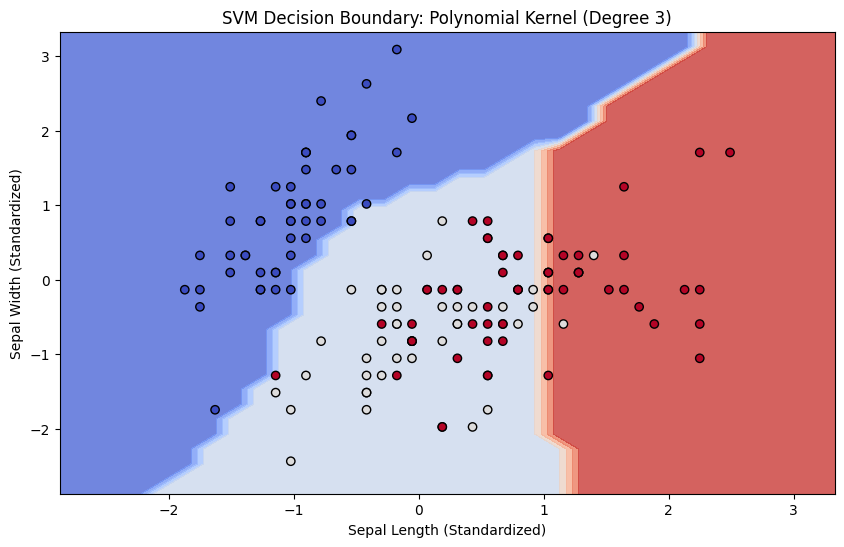

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#loading the dataset
from sklearn.datasets import load_iris
iris_data=load_iris()
#print(iris_data.DESCR)
#loading a dataframe and target
x=iris_data.data[:,:2]
y=iris_data.target

#Scale the data
scaler=StandardScaler()
x_scale=scaler.fit_transform(x)

#Train SVM with polynommial kernel
poly_svm=SVC(kernel='poly',degree=3,C=1.0)
poly_svm.fit(x_scale,y)

#Create a mesh grid to plot the decision boundries
h=0.2
x_min,x_max=x_scale[:,0].min()-1,x_scale[:,0].max()+1
y_min,y_max=x_scale[:,0].min()-1,x_scale[:,0].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

#Predict across the entire mesh grid
Z=poly_svm.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

#plotting 
plt.figure(figsize=(10,6))
plt.contourf(xx,yy,Z,cmap=plt.cm.coolwarm,alpha=0.8)
plt.scatter(x_scale[:,0],x_scale[:,1],c=y,cmap=plt.cm.coolwarm,edgecolors='k')
plt.xlabel('Sepal Length (Standardized)')
plt.ylabel('Sepal Width (Standardized)')
plt.title('SVM Decision Boundary: Polynomial Kernel (Degree 3)')
plt.show()

25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy:

In [5]:
#Load the dataset 
from sklearn.datasets import load_breast_cancer
breast_data=load_breast_cancer()
#print(breast_data.DESCR)

#Crating a dataframe
x=pd.DataFrame(breast_data.data,columns=breast_data.feature_names)
y=pd.DataFrame(breast_data.target,columns=['Severity'])

#splitting the data into train test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#creationg of naives model training it
from sklearn.naive_bayes import GaussianNB
clf=GaussianNB()
clf.fit(x_train,y_train)

#Predicting the Severity 
y_pred=clf.predict(x_test)

#Checking the accuracy of model
print('The classification report is :')
print(classification_report(y_test,y_pred))
print('The confusion matrix is',confusion_matrix(y_test,y_pred))
print('The accuracy score is :',accuracy_score(y_test,y_pred))

The classification report is :
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        63
           1       0.95      0.96      0.96       108

    accuracy                           0.95       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

The confusion matrix is [[ 58   5]
 [  4 104]]
The accuracy score is : 0.9473684210526315


26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20
Newsgroups dataset.

In [6]:
#Load the dataset
from sklearn.datasets import fetch_20newsgroups
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups=fetch_20newsgroups(subset='all',categories=categories,remove=('headers','footers','quotes'))
#print(news_data.DESCR)
x=newsgroups.data
y=newsgroups.target

#Splitting the data into train test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

# Convert text to numerical vectors using TF-IDF
# TF-IDF stands for Term Frequency-Inverse Document Frequency
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(stop_words='english')
x_train_transformed=vectorizer.fit_transform(x_train)
x_test_transformed=vectorizer.transform(x_test)

# Train the Multinomial Naive Bayes Classifier
# Alpha=1.0 is the Laplace smoothing parameter
from sklearn.naive_bayes import MultinomialNB
clf=MultinomialNB(alpha=1)
clf.fit(x_train_transformed,y_train)

# Make predictions
y_pred=clf.predict(x_test_transformed)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=newsgroups.target_names))

Accuracy: 80.23%

Classification Report:
                        precision    recall  f1-score   support

           alt.atheism       0.99      0.37      0.54       251
         comp.graphics       0.94      0.93      0.93       281
               sci.med       0.97      0.87      0.92       301
soc.religion.christian       0.60      0.98      0.74       295

              accuracy                           0.80      1128
             macro avg       0.87      0.79      0.78      1128
          weighted avg       0.87      0.80      0.79      1128



27. Write a Python program to train an SVM Classifier with different C values and compare the decision
boundaries visually.

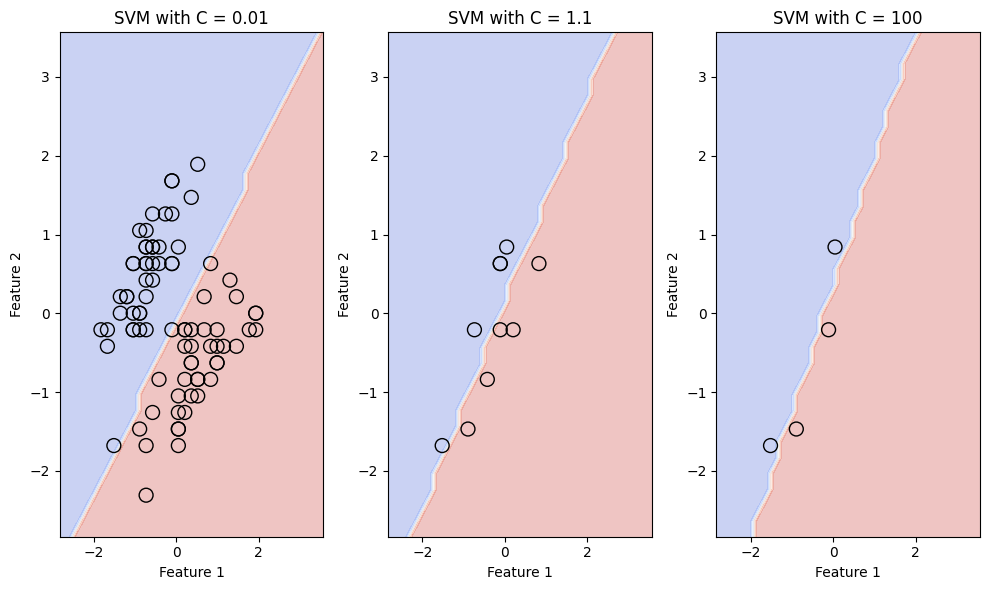

In [7]:
#loading the dataset
from sklearn.datasets import load_iris
iris_data=load_iris()
#print(iris_data.DESCR)
#loading a dataframe and target
x=iris_data.data[:100,:2]
y=iris_data.target[:100]

#Scale the data
scaler=StandardScaler()
x_scale=scaler.fit_transform(x)

c_values=[0.01,1.1,100]
plt.figure(figsize=(10,6))
#Train SVM with polynommial kernel
for i,C in enumerate(c_values):
    lin_svm=SVC(kernel='linear',C=C)
    lin_svm.fit(x_scale,y)

#Create a mesh grid to plot the decision boundries
    h=0.2
    x_min,x_max=x_scale[:,0].min()-1,x_scale[:,1].max()+1
    y_min,y_max=x_scale[:,0].min()-1,x_scale[:,1].max()+1
    xx,yy=np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))

    #Predict the plot
    Z=lin_svm.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)

    plt.subplot(1,3,i+1)
    plt.contourf(xx,yy,Z,cmap=plt.cm.coolwarm,alpha=0.3)
    plt.scatter(lin_svm.support_vectors_[:,0],lin_svm.support_vectors_[:,1],linewidths=1,s=100,facecolors='none',edgecolors='k')
    plt.title(f'SVM with C = {C}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.tight_layout()
# 
plt.show()

1. Small $C$ (e.g., $C = 0.01$) — "The Relaxed Model"

* The Margin: The "gap" between the two classes will be very wide.

* Misclassifications: The model is "soft." It allows some points to cross over into the wrong territory or fall inside the margin to keep the boundary smooth.

* Goal: Avoids overfitting. It ignores local noise to find a more general trend.

2. Medium $C$ (e.g., $C = 1$) — "The Balanced Model"
* This is the default in scikit-learn. 

* It tries to find a balance between a wide margin and minimizing classification errors.

3. Large $C$ (e.g., $C = 100$) — "The Strict Model"

* The Margin: The "gap" will be very narrow.

* Misclassifications: The model is "hard." It works extremely hard to ensure every single training point is on the correct side of the line.

* Goal: High accuracy on training data, but high risk of overfitting. The boundary may look "zig-zaggy" as it tries to dodge individual points.

28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with
binary features.

In [8]:
# Generate a synthetic binary classification dataset
# We create 1000 samples with 10 features
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

# Binarize the features
# Bernoulli NB expects binary (0 or 1) data. 
# We'll convert positive values to 1 and non-positive to 0.
x_binary=(x>0).astype(int)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_binary, y, test_size=0.2, random_state=1)

# Train the Bernoulli Naïve Bayes Classifier
# binarize=None because we manually binarized the data above.
# alpha=1.0 is the Laplace smoothing parameter.
from sklearn.naive_bayes import BernoulliNB
clf=BernoulliNB(alpha=1.0)
clf.fit(x_train,y_train)

#Predict the value
y_pred=clf.predict(x_test)

# Evaluate the model
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 88.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       103
           1       0.89      0.87      0.88        97

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



29. Write a Python program to apply feature scaling before training an SVM model and compare results with
unscaled data.

In [9]:
#Loading the housing dataset
from sklearn.datasets import fetch_california_housing
housing_data=fetch_california_housing()
#print(housing_data.DESCR)
#Converting the data into dataframe
x=pd.DataFrame(housing_data.data,columns=housing_data.feature_names)
y=pd.DataFrame(housing_data.target,columns=['Price'])

#splitting the data into train test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)


#creating a SVM regressor and training it before scaling the data
reg=SVR()
reg.fit(x_train,y_train)

#predicting the value for testing data
y_pred=reg.predict(x_test)

#Checking the accuracy of the regressor model before scaling the data
print('The accuracy of model before scaling the data')
print('The mean squared error of the model is :',mean_squared_error(y_test,y_pred))

#scale the data(Crucial step for SVR)
scale=StandardScaler()
x_train_scale=scale.fit_transform(x_train)
x_test_scale=scale.transform(x_test)

#creating a SVM regressor and training it after scaling the data
reg=SVR()
reg.fit(x_train_scale,y_train)

#predicting the value for testing data
y_pred=reg.predict(x_test_scale)

#Checking the accuracy of the regressor model after scaling the data
print('The accuracy of model after scaling the data')
print('The mean squared error of the model is :',mean_squared_error(y_test,y_pred))

The accuracy of model before scaling the data
The mean squared error of the model is : 1.337848635274566
The accuracy of model after scaling the data
The mean squared error of the model is : 0.35556095536170024


30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and
after Laplace Smoothing.

In [10]:
# 1. Generate a synthetic continuous dataset
X, y = make_classification(n_samples=500, n_features=5, n_classes=2,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a Standard Gaussian NB (Default var_smoothing = 1e-9)
model_raw = GaussianNB()
model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)

# 3. Train a Smoothed Gaussian NB (High var_smoothing)
# This acts similarly to Laplace smoothing by "stretching" the distribution
model_smooth = GaussianNB(var_smoothing=1.0)
model_smooth.fit(X_train, y_train)
y_pred_smooth = model_smooth.predict(X_test)

# 4. Compare Results
print(f"Accuracy without smoothing: {accuracy_score(y_test, y_pred_raw) * 100:.2f}%")
print(f"Accuracy with high smoothing: {accuracy_score(y_test, y_pred_smooth) * 100:.2f}%")

# 5. Check how many predictions actually changed
changes = np.sum(y_pred_raw != y_pred_smooth)
print(f"\nNumber of samples where smoothing changed the prediction: {changes}")

Accuracy without smoothing: 92.00%
Accuracy with high smoothing: 90.00%

Number of samples where smoothing changed the prediction: 4


31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C,
gamma, kernel).

In [47]:
#Creating synthetic data
x,y=make_classification(n_samples=500,n_features=10,n_classes=2,n_clusters_per_class=2,n_redundant=0,n_repeated=0)

#Splitting the data into train test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Scaling the data
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#Hyperparameter tuning with SVC
param_grid={'C':[0.1,1,10],
            'gamma':[10,1,0.1],
            'kernel':['linear','poly','rbf','sigmoid']}
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=param_grid,cv=5,verbose=0)
#Training the data
grid.fit(x_train_scaled,y_train)
#Predicting the data
y_pred=grid.predict(x_test_scaled)

#results
print("\n--- Best Parameters Found ---")
print(grid.best_params_)

print("\n--- Best Estimator ---")
print(grid.best_estimator_)

print("\n--- Best Estimator ---")
print(grid.best_score_)

#Final evaluations
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred))
print('\n---The accuracy score---')
print(accuracy_score(y_test, y_pred))


--- Best Parameters Found ---
{'C': 1, 'gamma': 0.1, 'kernel': 'sigmoid'}

--- Best Estimator ---
SVC(C=1, gamma=0.1, kernel='sigmoid')

--- Best Estimator ---
0.9400000000000001

Final Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        66
           1       0.96      0.92      0.94        84

    accuracy                           0.93       150
   macro avg       0.93      0.94      0.93       150
weighted avg       0.94      0.93      0.93       150


---The accuracy score---
0.9333333333333333


32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and
check it improve accuracy.

In [54]:
#Creating synthetic data
x,y=make_classification(n_samples=1000,n_features=10,n_classes=2,n_clusters_per_class=1,weights=[0.9,0.1],n_redundant=0,n_repeated=0,flip_y=0,random_state=42)

#Splitting the data into train test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Scaling the data
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#Training SVC model (No weighting)
clf=SVC(kernel='rbf')
clf.fit(x_train,y_train)
y_pred_standard=clf.predict(x_test)

#Training SVC model with class weighting
clf=SVC(kernel='rbf',class_weight='balanced')
clf.fit(x_train,y_train)
y_pred_weighted=clf.predict(x_test)

#Compare Results
print("--- Standard SVM (Imbalanced) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_standard):.2f}")
print(classification_report(y_test, y_pred_standard))

print("\n--- Weighted SVM (Balanced) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_weighted):.2f}")
print(classification_report(y_test, y_pred_weighted))

--- Standard SVM (Imbalanced) ---
Overall Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       280
           1       1.00      0.80      0.89        20

    accuracy                           0.99       300
   macro avg       0.99      0.90      0.94       300
weighted avg       0.99      0.99      0.99       300


--- Weighted SVM (Balanced) ---
Overall Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       280
           1       0.73      0.80      0.76        20

    accuracy                           0.97       300
   macro avg       0.86      0.89      0.87       300
weighted avg       0.97      0.97      0.97       300



Does it actually "Improve Accuracy"?
This is the most important takeaway from this exercise: Overall accuracy usually drops, but "Class 1" accuracy improves.

* Standard SVM: Might achieve 92% accuracy simply by predicting "Class 0" for every single person. It looks good on paper, but it failed to find a single person in the minority class (e.g., failing to detect a rare disease).

* Weighted SVM: Might drop to 88% overall accuracy, but your Recall for Class 1 will jump significantly.

33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.

In [56]:
# 1. Sample Dataset (In a real scenario, you'd load a CSV like 'spam.csv')
data = {
    'text': [
        'Free entry in 2 a weekly comp to win FA Cup final tickets 21st May.',
        'Hi, how are you? Are we still meeting for lunch today?',
        'WINNER!! As a valued network customer you have been selected to receive a £900 prize reward!',
        'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free!',
        'I’m gonna be home soon and i don’t want to talk about this stuff anymore tonight, k?',
        'URGENT! Your mobile number has been awarded a £2000 bonus prize. Claim now.'
    ],
    'label': ['spam', 'ham', 'spam', 'spam', 'ham', 'spam']
}

df = pd.DataFrame(data)

# 2. Preprocessing: Convert text to numerical data
# CountVectorizer counts the frequency of each word in the email
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(df['text'])
y = df['label']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train the Multinomial Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test)

# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Test with a custom email
sample_email = ["Congratulations! You've won a free gift card. Click here to claim."]
sample_counts = cv.transform(sample_email)
prediction = model.predict(sample_counts)
print(f"\nNew Email Prediction: {prediction[0]}")

Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

         ham       0.50      1.00      0.67         1
        spam       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


New Email Prediction: spam


34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and
compare their accuracy.

SVM Accuracy: 97.66%
Naïve Bayes Accuracy: 93.57%


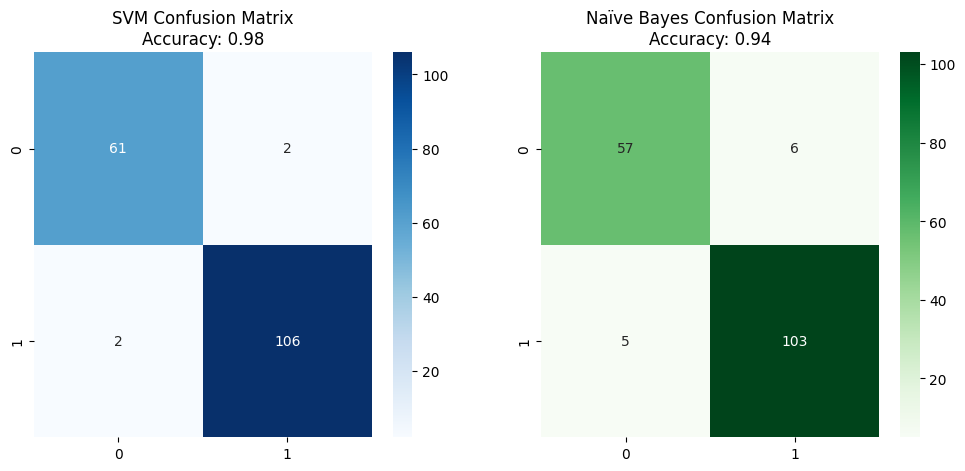

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load and Preprocess Data
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling is mandatory for SVM, though not strictly required for Naive Bayes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train SVM Classifier
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

# 3. Train Naïve Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)
nb_acc = accuracy_score(y_test, nb_pred)

# 4. Compare Accuracy
print(f"SVM Accuracy: {svm_acc * 100:.2f}%")
print(f"Naïve Bayes Accuracy: {nb_acc * 100:.2f}%")

# 5. Visualize Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title(f'SVM Confusion Matrix\nAccuracy: {svm_acc:.2f}')

sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title(f'Naïve Bayes Confusion Matrix\nAccuracy: {nb_acc:.2f}')

plt.show()

35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare
results.

In [65]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scaling (Good practice for consistent feature scoring)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Baseline: Train Naïve Bayes with ALL 30 features
nb_full = GaussianNB()
nb_full.fit(X_train, y_train)
full_acc = accuracy_score(y_test, nb_full.predict(X_test))

# 5. Feature Selection: Pick the top 5 features
# We use f_classif (ANOVA) which is great for continuous data like this
selector = SelectKBest(score_func=f_classif, k=5)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# 6. Selected: Train Naïve Bayes with ONLY top 5 features
nb_selected = GaussianNB()
nb_selected.fit(X_train, y_train)
selected_acc = accuracy_score(y_test, nb_selected.predict(X_test))

# 7. Compare Results
print(f"--- Feature Selection Comparison ---")
print(f"Accuracy with all 30 features: {full_acc * 100:.2f}%")
print(f"Accuracy with top 5 features:  {selected_acc * 100:.2f}%")

# Identify which features were kept
mask = selector.get_support()
selected_features = [data.feature_names[i] for i in range(len(mask)) if mask[i]]
print(f"\nTop 5 Features selected: {selected_features}")

--- Feature Selection Comparison ---
Accuracy with all 30 features: 93.57%
Accuracy with top 5 features:  94.74%

Top 5 Features selected: [np.str_('mean perimeter'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst concave points')]


36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO)
strategies on the Wine dataset and compare their accuracy.

In [68]:
# 1. Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# 2. Split and Scale
# Scaling is crucial for SVM to find the optimal hyperplane
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. SVM with One-vs-Rest (OvR) Strategy
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
ovr_strategy=OneVsRestClassifier(SVC(kernel='linear',random_state=42))
ovr_strategy.fit(X_train,y_train)
ovr_pred = ovr_strategy.predict(X_test)
ovr_acc = accuracy_score(y_test, ovr_pred)

# 4. SVM with One-vs-One (OvO) Strategy
ovo_strategy = OneVsOneClassifier(SVC(kernel='linear', random_state=42))
ovo_strategy.fit(X_train, y_train)
ovo_pred = ovo_strategy.predict(X_test)
ovo_acc = accuracy_score(y_test, ovo_pred)

# 5. Results
print(f"--- Strategy Comparison (Wine Dataset) ---")
print(f"One-vs-Rest (OvR) Accuracy: {ovr_acc * 100:.2f}%")
print(f"One-vs-One (OvO) Accuracy:  {ovo_acc * 100:.2f}%")

--- Strategy Comparison (Wine Dataset) ---
One-vs-Rest (OvR) Accuracy: 98.15%
One-vs-One (OvO) Accuracy:  98.15%


37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast
Cancer dataset and compare their accuracy

In [70]:
# 1. Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scaling (Mandatory for SVM kernels to function correctly)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Define the Kernels to compare
kernels = ['linear', 'poly', 'rbf']
results = {}

for k in kernels:
    # Initialize and train the model
    # We use degree=3 for poly as a standard baseline
    model=SVC(kernel=k,degree=3,gamma='scale')
    model.fit(X_train,y_train)
    
    # Predict and calculate accuracy
    predictions=model.predict(X_test)
    acc=accuracy_score(predictions,y_test)
    results[k]=acc
    
# 5. Compare the results
print("--- SVM Kernel Accuracy Comparison ---")
for kernel_name, accuracy in results.items():
    print(f"{kernel_name.capitalize()} Kernel: {accuracy * 100:.2f}%")

--- SVM Kernel Accuracy Comparison ---
Linear Kernel: 97.66%
Poly Kernel: 89.47%
Rbf Kernel: 97.66%


38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the
average accuracy.

In [71]:
# 1. Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Create a Pipeline
# It is best practice to scale inside the cross-validation loop 
# to avoid data leakage. A Pipeline handles this automatically.
from sklearn.pipeline import Pipeline
pipeline=Pipeline([('scaler',StandardScaler()),('svm',SVC(kernel='rbf',C=1.0,gamma='scale'))])

# 3. Initialize Stratified K-Fold
# n_splits=5 means the data is divided into 5 parts
from sklearn.model_selection import StratifiedKFold,cross_val_score
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# 4. Perform Cross-Validation
# This runs the training/testing process 5 times
cv_results =cross_val_score(pipeline,X,y,cv=skf,scoring='accuracy')

# 5. Output results
print(f"Individual Fold Accuracies: {cv_results}")
print(f"Average Accuracy: {np.mean(cv_results) * 100:.2f}%")
print(f"Standard Deviation: {np.mean(cv_results):.4f}")

Individual Fold Accuracies: [0.99122807 0.94736842 0.97368421 0.99122807 0.98230088]
Average Accuracy: 97.72%
Standard Deviation: 0.9772


39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare
performance.

In [75]:
# 1. Load the dataset (Iris is a 3-class problem)
data = load_iris()
X = data.data
y = data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Model 1: Default Priors (Learned from the data)
model_default = GaussianNB()
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)

# 4. Model 2: Custom Priors
# We have 3 classes. Let's heavily bias it toward the first class (Setosa)
# The sum of priors must equal 1.0
custom_priors = [0.8, 0.1, 0.1]
model_custom=GaussianNB(priors=custom_priors)
model_custom.fit(X_train,y_train)
y_pred_custom = model_custom.predict(X_test)

# 5. Performance Comparison
print("--- Performance with Default Priors ---")
print(f"Priors used: {model_default.class_prior_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")

print("\n--- Performance with Custom Priors ---")
print(f"Priors used: {custom_priors}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")

print("\nDetailed Classification Report (Custom):")
print(classification_report(y_test, y_pred_custom, target_names=data.target_names))

--- Performance with Default Priors ---
Priors used: [0.2952381  0.35238095 0.35238095]
Accuracy: 0.9778

--- Performance with Custom Priors ---
Priors used: [0.8, 0.1, 0.1]
Accuracy: 0.9778

Detailed Classification Report (Custom):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and
compare accuracy.

In [81]:
# 1. Load data (30 features total)
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Preprocessing: SVMs are sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. Baseline Model: SVM with all 30 features
# We use a linear kernel because RFE requires the 'coef_' attribute to rank features
svm_baseline = SVC(kernel="linear")
svm_baseline.fit(X_train, y_train)
y_pred_base = svm_baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

# 4. RFE Model: Select the top 5 most informative features
from sklearn.feature_selection import RFE
selector=RFE(estimator=svm_baseline,n_features_to_select=5,step=1)
selector.fit(X_train,y_train)

# Transform the data to only include the top 5 features
X_train=selector.transform(X_train)
X_test=selector.transform(X_test)
# Train a new SVM on the reduced feature set
svm_rfe = SVC(kernel="linear")
svm_rfe.fit(X_train, y_train)
y_pred_rfe = svm_rfe.predict(X_test)
acc_rfe = accuracy_score(y_test, y_pred_rfe)

# 5. Results
print(f"Total features available: {X.shape[1]}")
print(f"Accuracy with ALL features: {acc_base:.4f}")
print("-" * 30)
print(f"Features selected by RFE: {data.feature_names[selector.support_]}")
print(f"Accuracy with TOP 5 features: {acc_rfe:.4f}")

Total features available: 30
Accuracy with ALL features: 0.9766
------------------------------
Features selected by RFE: ['mean concave points' 'area error' 'worst texture' 'worst area'
 'worst symmetry']
Accuracy with TOP 5 features: 0.9591


41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and
F1-Score instead of accuracy.

In [83]:
#loading the dataset
iris_data=load_iris()
#print(iris_data.DESCR)
#loading a dataframe and target
x=pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
y=pd.DataFrame(iris_data.target,columns=['Class'])

#Splitting into training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

model=SVC(kernel='linear')
#training the model
model.fit(x_train,y_train)
#testing the data
y_pred=model.predict(x_test)

#Checking the accuracy of model
from sklearn.metrics import recall_score,precision_score,f1_score
print('The classification report is :')
print(classification_report(y_test,y_pred))
print('The recall score is',recall_score(y_test,y_pred,average='weighted'))
print('The precision score is :',precision_score(y_test,y_pred,average='weighted'))
print('The f1 score is :',f1_score(y_test,y_pred,average='weighted'))

The classification report is :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

The recall score is 1.0
The precision score is : 1.0
The f1 score is : 1.0


42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss
(Cross-Entropy Loss).

In [85]:
# 1. Setup Data
data = load_iris()
X, y = data.data, data.target

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train Naïve Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# 3. Get Predictions
# We need labels for Accuracy
y_pred_labels = model.predict(X_test)

# We need probabilities for Log Loss
y_pred_proba=model.predict_proba(X_test)

# 4. Evaluation
from sklearn.metrics import log_loss
acc = accuracy_score(y_test, y_pred_labels)
loss=log_loss(y_test,y_pred_proba)

print(f"Model Accuracy: {acc:.4f}")
print(f"Log Loss (Cross-Entropy): {loss:.4f}")

# Example of what predict_proba looks like for the first test sample:
print(f"\nProbabilities for first sample: {y_pred_proba[0]}")
print(f"True class for first sample: {y_test[0]}")

Model Accuracy: 0.9778
Log Loss (Cross-Entropy): 0.0490

Probabilities for first sample: [4.15880005e-88 9.95527834e-01 4.47216606e-03]
True class for first sample: 1


43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

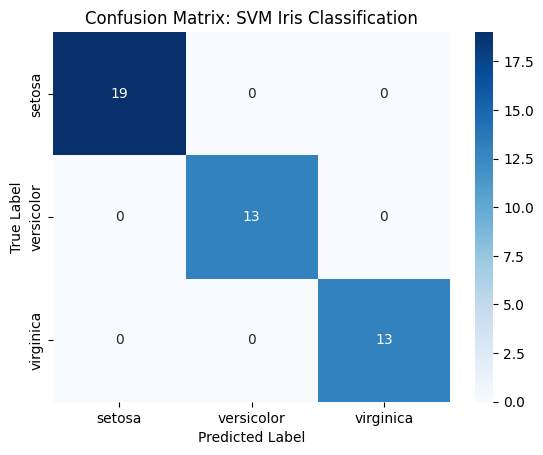

In [87]:
# 1. Load the dataset
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train SVM Classifier
# Using an RBF kernel (default) for non-linear boundaries
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# 4. Generate Predictions
y_pred = model.predict(X_test)

# 5. Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 6. Visualize using Seaborn
plt.Figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: SVM Iris Classification')
plt.show()

44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute
Error (MAE) instead of MSE.

In [90]:
#Loading the housing dataset
from sklearn.datasets import fetch_california_housing
housing_data=fetch_california_housing()
#print(housing_data.DESCR)
#Converting the data into dataframe
x=pd.DataFrame(housing_data.data,columns=housing_data.feature_names)
y=pd.DataFrame(housing_data.target,columns=['Price'])

#splitting the data into train test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)


#creating a SVM regressor and training it 
reg=SVR()
reg.fit(x_train,y_train)

#predicting the value for testing data
y_pred=reg.predict(x_test)

#Checking the accuracy of the regressor model
from sklearn.metrics import mean_absolute_error
print('The accuracy of model before scaling the data')
print('The mean absolute error of the model is :',mean_absolute_error(y_test,y_pred))


The accuracy of model before scaling the data
The mean absolute error of the model is : 0.8634368287217753


45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC
score.

In [91]:
# Generate a synthetic binary classification dataset
# We create 1000 samples with 10 features
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

# Binarize the features
# Bernoulli NB expects binary (0 or 1) data. 
# We'll convert positive values to 1 and non-positive to 0.
x_binary=(x>0).astype(int)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_binary, y, test_size=0.2, random_state=1)

# Train the Bernoulli Naïve Bayes Classifier
# binarize=None because we manually binarized the data above.
# alpha=1.0 is the Laplace smoothing parameter.
from sklearn.naive_bayes import BernoulliNB
clf=BernoulliNB(alpha=1.0)
clf.fit(x_train,y_train)

#Predict the value
y_pred=clf.predict(x_test)

# Evaluate the model
from sklearn.metrics import roc_auc_score
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred) * 100:.2f}%")

Accuracy Score: 93.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        92
           1       0.89      1.00      0.94       108

    accuracy                           0.93       200
   macro avg       0.94      0.92      0.93       200
weighted avg       0.94      0.93      0.93       200

ROC AUC Score: 92.39%


46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

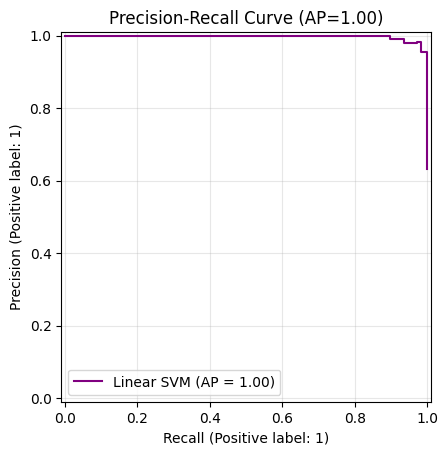

In [92]:
# 1. Load data
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train SVM Classifier
# We use a linear kernel here, but RBF works similarly
model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

# 4. Get decision scores
# Precision-Recall curves need a ranking/probability score.
# For SVM, we use decision_function (distance to the hyperplane)
y_scores=model.decision_function(X_test)

# 5. Calculate Average Precision (AP)
from sklearn.metrics import average_precision_score,precision_recall_curve,PrecisionRecallDisplay
average_precision=average_precision_score(y_test,y_scores)

# 6. Visualization using PrecisionRecallDisplay
# This is the modern, built-in way to plot the curve in Scikit-Learn
display=PrecisionRecallDisplay.from_estimator(model,X_test,y_test,name='Linear SVM',color='purple')
display.ax_.set_title(f"Precision-Recall Curve (AP={average_precision:.2f})")
plt.grid(alpha=0.3)
plt.show()
